<a href="https://colab.research.google.com/github/7-atharva/AIML-Intern/blob/main/Practice_AIML%20Task%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1 Importing an Libraries
import pandas as pd # Data manipulation, cleaning, and analysis (DataFrames)
import numpy as np  # Numerical computations and matrix operations (Arrays)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Step 2 Loading an DataSet and Understanding an Data
df = pd.read_csv("/content/ai4i2020.csv")

df.head()
# df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
df.shape   # shows no of rows and columns in Dataset

(10000, 14)

In [ ]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
# Step 3 Now Doing an Data Cleaning

#Now checking an missing values in each columns
print(df.isnull().sum())   # we can see that in any feature(Column) there is any null values so it give the count of that

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [ ]:
# Remove duplicate rows (if any)
df.drop_duplicates(inplace=True)

In [ ]:
from logging import error
# Droping an Unnecessary columns (UDI and Product Id is not useful for Machine analysis)
df.drop(columns=["UDI", "Product ID"], inplace=True, errors='ignore')

In [ ]:
# Count how many machines failed vs not failed
print(df["Machine failure"].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


In [ ]:
# Feature Engineering
# Feature engineering helps create new useful columns that improve analysis and prediction.

# Create new column → Temperature difference
df["Temp_Diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]

# Create new column → Power (important machine metric)
df["Power"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]

# This two Features Helps to detect machine behavior better
# df

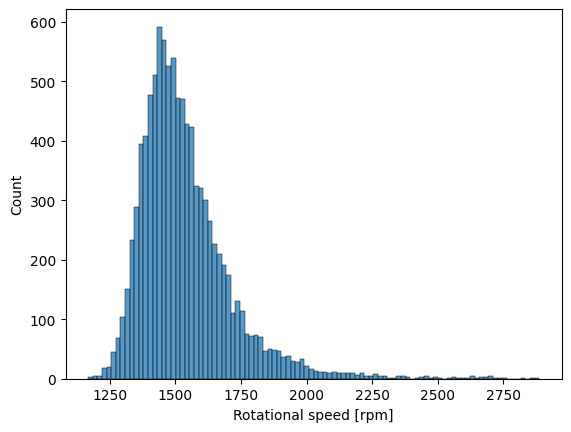

In [ ]:
# Plot distribution of rotational speed Understanding spread of data
sns.histplot(df["Rotational speed [rpm]"])

# Show graph
plt.show()

# Histogram shows how data values are distributed across ranges.

# This graph shows the distribution of rotational speed. Most machines operate around 1500 rpm.
# The histogram of Rotational speed [rpm] shows how many machines in dataset operate at specific speeds.
# Such as :
# 1) The Peak: Most machines operate around 1500 RPM, which is the center of the distribution.
# 2) The Spread: Most data points are tightly packed between 1400 and 1700 RPM.
# 3) Outliers: There is a 'tail' on the right side, showing that a few machines run at much higher speeds (up to nearly 3000 RPM), which could be instances of unusual operation or potential failure conditions.

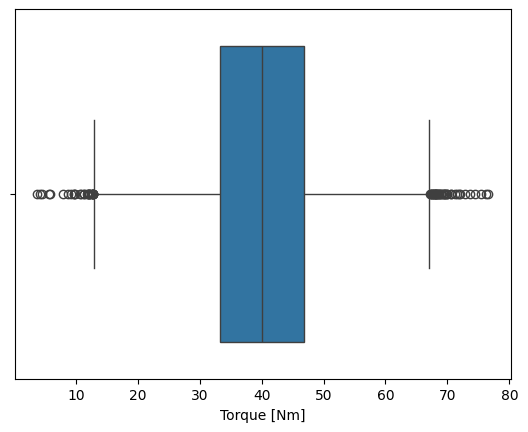

In [ ]:
# BoxPlot Helps to find the Outliers it detects the abnormal values
# Boxplot helps to detect outliers and understand data spread.
sns.boxplot(x=df["Torque [Nm]"])
plt.show()

# The BoxPlot for Torque shows the distribution and spread of the data :

# The Box: Represents the middle 50% of your data. The line inside the box is the Median (the middle value).
# The Whiskers: These lines extending from the box show the typical range of the torque values.
# The Dots (Outliers): Those individual points on the far left and far right are outliers. These represent machines with unusually low or high torque compared to the rest, which might indicate abnormal operating conditions.

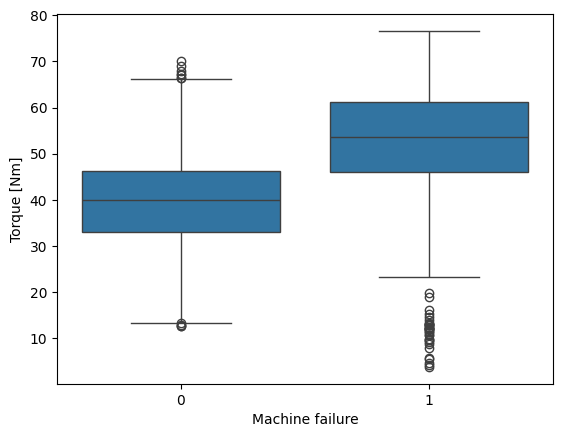

In [ ]:
# Now comparing the tarque with Machine failure
sns.boxplot(x="Machine failure", y="Torque [Nm]", data=df)
plt.show()
# Understand what causes failure
# Torque is the rotating force in a machine. Very high torque puts extra stress on machine parts, which can increase chances of failure.

# Similar Averages: The 'middle line' (median) for both groups is very close, meaning most machines—failed or not—run at similar torque levels.
# The Difference: The 'Failure' box (1) is much taller than the 'No Failure' box (0). This shows that machines that fail are much more unpredictable and have wider swings in torque.
# Extreme Outliers: You can see dots at the very top and very bottom of the 'Failure' side. This tells you that extreme high torque and extreme low torque are the main zones where machines actually break down.

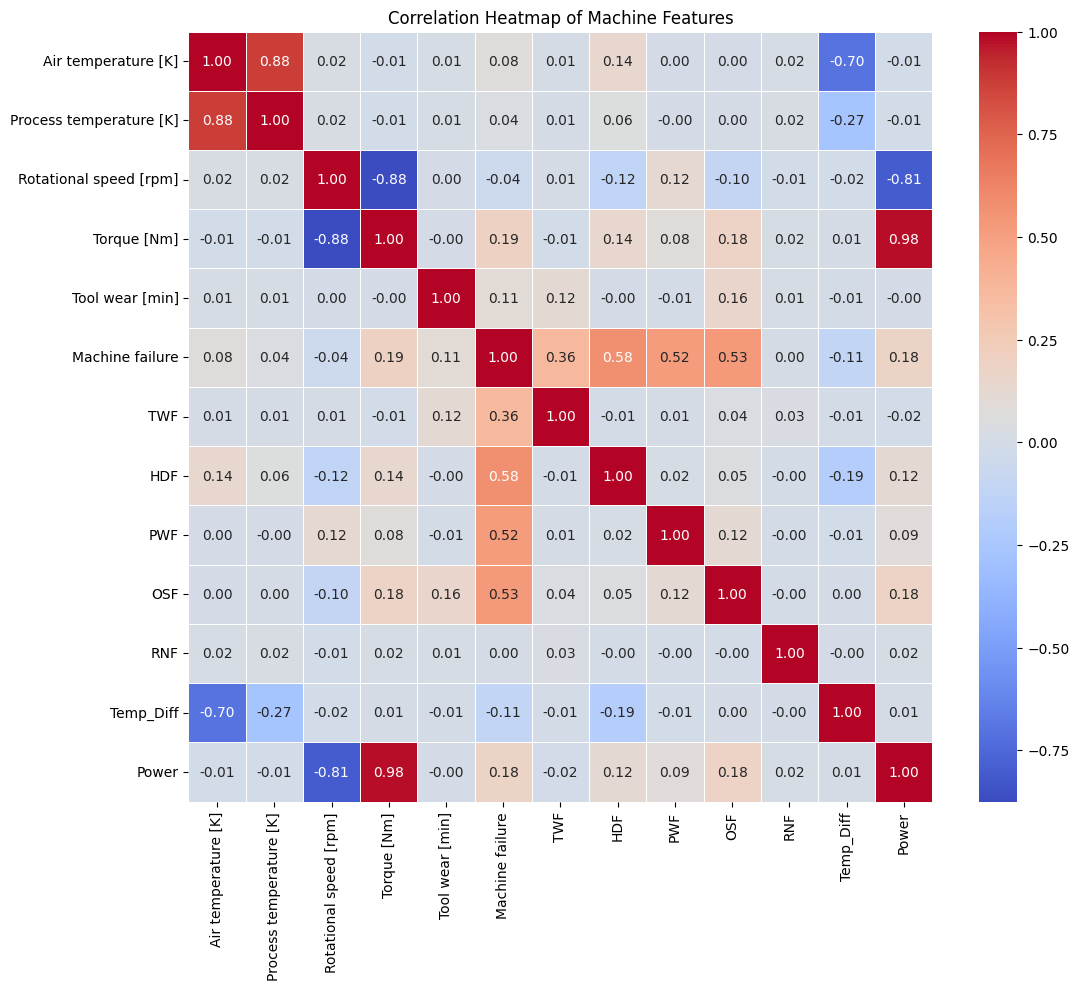

In [ ]:
import numpy as np
# 4. Correlation Heatmap
# Calculate correlation between numeric columns only
corr = df.corr(numeric_only=True)

# Set up the matplotlib figure size
plt.figure(figsize=(12, 10))

# Plot Heatmap with larger size and better formatting
sns.heatmap(corr,annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Machine Features")
plt.show()

# Output
# Heatmap shows relationships between features using correlation values. Correlation shows how strongly two variables are related.
# Example: High torque may relate to machine failure.

# This Correlation Heatmap tells you how different features relate to each other:

# Red/Warm colors (near 1.0): Show a strong positive relationship (e.g., as Air Temperature goes up, Process Temperature also goes up).
# Blue/Cool colors (near -0.88): Show a strong inverse relationship (e.g., when Rotational Speed goes up, Torque usually goes down).
# Near 0: Means the two features don't have a clear linear relationship.


# The heatmap shows the correlation between all numeric features in dataset :

# Strong Positive Connection (Red): Notice the 0.88 between 'Air temperature' and 'Process temperature'. This means as the air gets hotter, the machine's internal process temperature almost always follows.
# Strong Negative Connection (Blue): Notice the -0.88 between 'Torque' and 'Rotational speed'. This means when the machine spins faster, the twisting force (torque) drops significantly.
# Machine Failure Indicators: Look at the 'Machine failure' row. Features like HDF, PWF, and OSF have higher numbers compared to others, suggesting these specific failure modes are the strongest indicators that a general machine failure is occurring.
# No Connection (White/Light): Values near 0.00 (like 'RNF' vs 'Torque') mean those two things have nothing to do with each other.

In [ ]:
# Step 7 : Anomaly Detection
# Calculate thershold (mean + 2*std)
thershold = df["Torque [Nm]"].mean() + 2 * df["Torque [Nm]"].std()

# Filter abnormal values
anomalies = df[df["Torque [Nm]"] > thershold]

# Showing anomalies in dataset
print(anomalies.head())

    Type  Air temperature [K]  Process temperature [K]  \
69     L                298.9                    309.0   
126    L                299.0                    308.6   
160    L                298.4                    308.2   
168    L                298.4                    308.3   
207    M                298.4                    308.7   

     Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  \
69                     1410         65.7              191                1   
126                    1329         60.5              120                0   
160                    1282         60.7              216                1   
168                    1433         62.3               20                1   
207                    1421         60.7              119                1   

     TWF  HDF  PWF  OSF  RNF  Temp_Diff    Power  
69     0    0    1    1    0       10.1  92637.0  
126    0    0    0    0    0        9.6  80404.5  
160    0    0    0    1    0 

Ouput

The formula used for anomaly detection identifies points that significantly deviate from the average. Here's a breakdown of how it works and what the results tell us:

1. How the Formula Works
The code uses a statistical approach called Standard Deviation Thresholding:

* **mean():** This is the average Torque (approx. 40 Nm).
* **std():** The standard deviation measures how much the data varies from the average (approx. 10 Nm).
* **The Calculation:** mean + 2 * std sets a limit at approximately 59.92 Nm.
* **The Logic:** In a normal distribution, about 95% of data points fall within 2 standard deviations. Anything beyond this (the remaining 5%) is statistically considered an 'unusual' or 'anomalous' event.

2. Analysis of the Output

Looking at the anomalies table:

* **High Failure Rate:** If you look at the Machine failure column in the anomalies you just printed, you'll see several 1s. This confirms that high torque is a very strong predictor of machine failure.
* **Specific Failure Modes:** Notice that for these anomalies, columns like PWF (Power Failure) and OSF (Overstrain Failure) are often triggered. This suggests that when torque crosses that ~60 Nm threshold, the machine is likely physically straining or drawing too much power.
* **Total Count:** Your analysis found 239 rows (out of 10,000) that exceed this torque limit, representing the most extreme operating conditions in your dataset.